In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [2]:
df=pd.read_csv("airlines_flights_data.csv")

In [3]:
df.rename(columns={'Duration(minutes)': 'duration'}, inplace=True)

In [4]:
df = df.drop('flight', axis=1, errors='ignore')

In [5]:
df.drop('index', axis=1, inplace=True)

In [6]:
df['stops'] = df['stops'].replace({
    'zero': 0,
    'one': 1,
    'two_or_more': 2
})

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_27056\3739732346.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stops'] = df['stops'].replace({


In [7]:
df = df.dropna()

In [8]:
df = df.drop_duplicates()

In [9]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,0,Night,Mumbai,Economy,130,1,5953
1,SpiceJet,Delhi,Early_Morning,0,Morning,Mumbai,Economy,140,1,5953
2,AirAsia,Delhi,Early_Morning,0,Early_Morning,Mumbai,Economy,130,1,5956
3,Vistara,Delhi,Morning,0,Afternoon,Mumbai,Economy,135,1,5955
4,Vistara,Delhi,Morning,0,Morning,Mumbai,Economy,140,1,5955


In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


# 🔷 Clean column names (VERY IMPORTANT ⭐)
df.columns = df.columns.str.strip().str.lower()

# 🔷 Check columns
print("Columns:", df.columns)

# 🔷 Remove outliers
q_high = df['price'].quantile(0.99)
df = df[df['price'] < q_high]

# 🔷 Check if required columns exist
required_cols = ['price', 'duration', 'days_left', 'stops', 'class', 'airline']

missing = [col for col in required_cols if col not in df.columns]

if missing:
    print("Missing columns:", missing)
else:
    # 🔷 Select features
    df = df[required_cols].copy()

    # 🔷 One-hot encoding
    df = pd.get_dummies(df, drop_first=True)

    # 🔷 Define X, y
    X = df.drop('price', axis=1)
    y = df['price']

    # 🔷 Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 🔷 Add constant
    X_train = sm.add_constant(X_train)
    X_test = sm.add_constant(X_test)

    # 🔷 Convert to float
    X_train = X_train.astype(float)
    X_test = X_test.astype(float)

    # 🔷 Fit Gamma GLM
    model = sm.GLM(
        y_train,
        X_train,
        family=sm.families.Gamma(sm.families.links.Log())
    ).fit()

    print(model.summary())

Columns: Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price'],
      dtype='object')
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  price   No. Observations:               235966
Model:                            GLM   Df Residuals:                   235956
Model Family:                   Gamma   Df Model:                            9
Link Function:                    Log   Scale:                         0.13037
Method:                          IRLS   Log-Likelihood:            -2.2823e+06
Date:                Thu, 02 Apr 2026   Deviance:                       27341.
Time:                        21:43:11   Pearson chi2:                 3.08e+04
No. Iterations:                    18   Pseudo R-squ. (CS):             0.9998
Covariance Type:            nonrobust                                         
                        coef    

In [11]:
# 🔷 Predictions on test data
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# Pseudo R² (IMPORTANT)
pseudo_r2 = 1 - (model.deviance / model.null_deviance)
print("Pseudo R²:", pseudo_r2)

MAE: 4691.027877838277
RMSE: 7881.778489854462
Pseudo R²: 0.9040849612592035


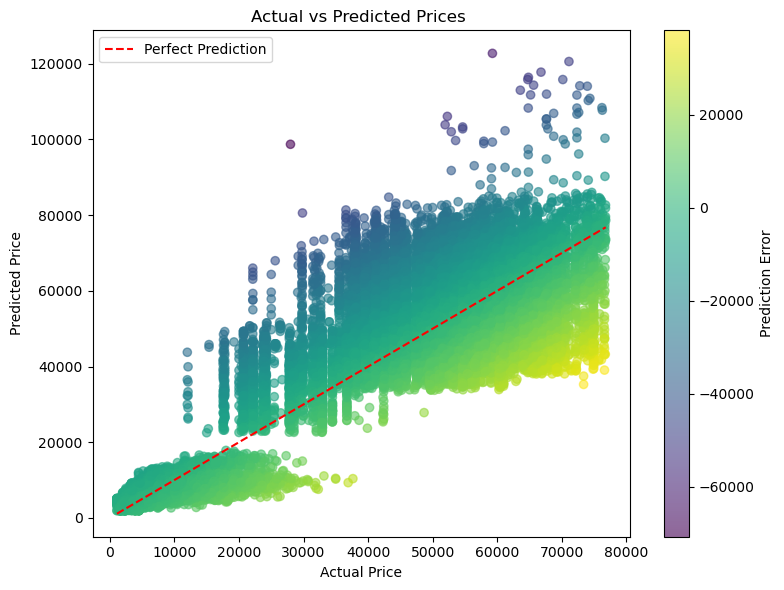

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Scatter plot with color based on error
errors = y_test - y_pred

scatter = plt.scatter(
    y_test, 
    y_pred, 
    c=errors, 
    cmap='viridis', 
    alpha=0.6
)

# Ideal line (perfect prediction)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

# Labels and title
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices ")

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Prediction Error')

# Legend
plt.legend()

plt.tight_layout()
plt.show()

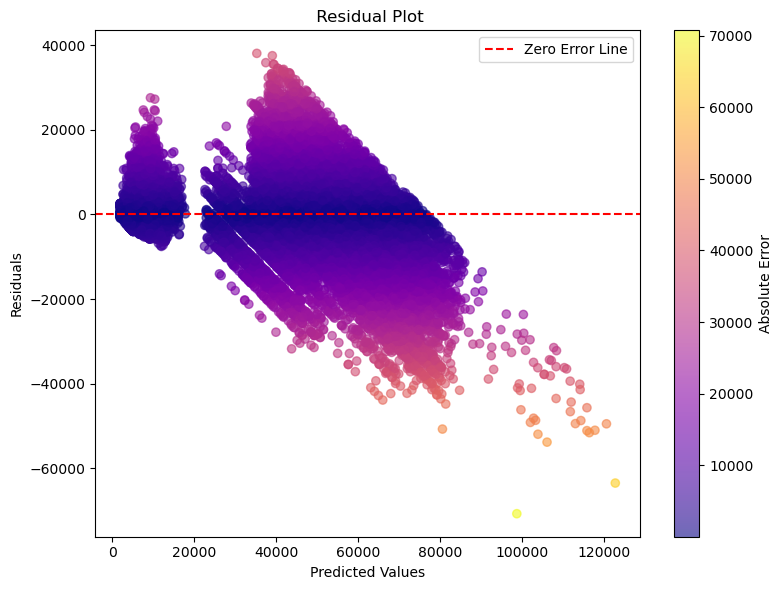

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

# Scatter with color based on magnitude of residuals
scatter = plt.scatter(
    y_pred,
    residuals,
    c=np.abs(residuals),   # color by error size
    cmap='plasma',
    alpha=0.6
)

# Reference line at 0
plt.axhline(y=0, color='red', linestyle='--', label='Zero Error Line')

# Labels and title
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(" Residual Plot")

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Absolute Error")

# Legend
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.drop(columns=['const'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

             Feature       VIF
0           duration  6.190104
1          days_left  4.123453
2              stops  7.598208
3      class_Economy  3.518194
4  airline_Air_India  3.269638
5   airline_GO_FIRST  1.618018
6     airline_Indigo  2.007835
7   airline_SpiceJet  1.238410
8    airline_Vistara  4.133540


In [16]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model.resid_response)
print("Durbin-Watson:", dw)

Durbin-Watson: 1.9931845521939036


In [17]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head())

        Actual     Predicted
133477    6909   6880.489089
78972     9201   7900.583604
138000   24686  11927.806628
17058     6832   5144.267323
53979     5102   7856.200908


In [18]:
# Example comparison table
comparison = pd.DataFrame({
    "Model": ["Gamma GLM"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [pseudo_r2]
})

print(comparison)

       Model          MAE        RMSE        R2
0  Gamma GLM  4691.027878  7881.77849  0.904085


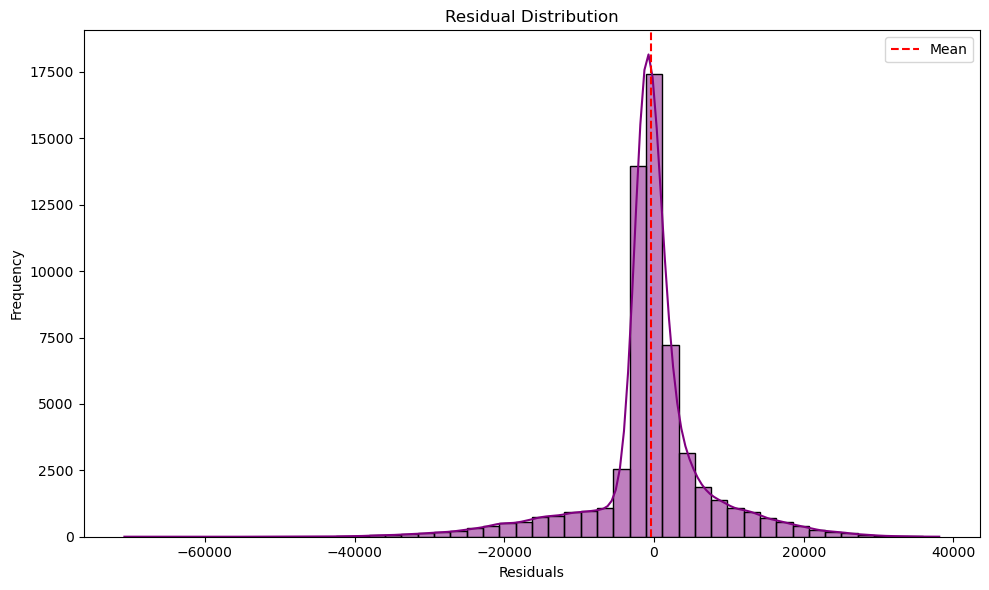

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals
residuals = y_test - y_pred

plt.figure(figsize=(10,6))

# Histogram + KDE
sns.histplot(
    residuals,
    bins=50,
    kde=True,
    color='purple',
    edgecolor='black'
)

# Mean line
plt.axvline(residuals.mean(), color='red', linestyle='--', label='Mean')

# Labels & Title
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Legend
plt.legend()

plt.tight_layout()
plt.show()

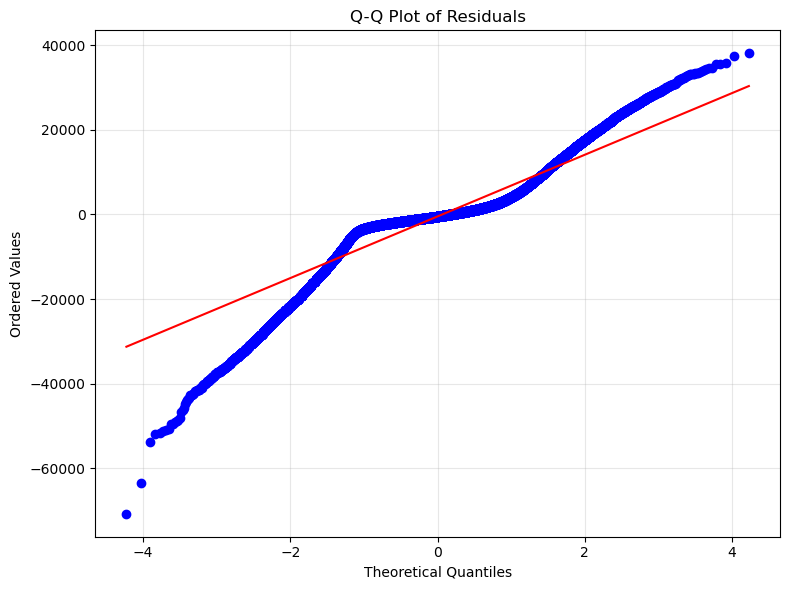

In [23]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Residuals
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=plt)

# Customize line and points
plt.gca().get_lines()[0].set_markerfacecolor('blue')   # data points
plt.gca().get_lines()[1].set_color('red')              # reference line

# Title and labels
plt.title("Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Values")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# 🔷 Feature Engineering
df['duration_sq'] = df['duration'] ** 2
df['duration_log'] = np.log1p(df['duration'])
df['days_left_log'] = np.log1p(df['days_left'])

In [20]:
df['duration_stops'] = df['duration'] * df['stops']
df['days_stops'] = df['days_left'] * df['stops']

In [21]:
df = df.drop(['duration', 'duration_sq'], axis=1, errors='ignore')

In [13]:
# 🔷 Select features
features = [
    'price',  'duration_log',
    'days_left', 'days_left_log',
    'stops', 'duration_stops',
    'class', 'airline'
]

df = df[features].copy()

# 🔷 Encoding
df = pd.get_dummies(df, drop_first=True)

# 🔷 X and y
X = df.drop('price', axis=1)
y = df['price']

# 🔷 Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔷 Add constant
import statsmodels.api as sm
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# 🔷 Convert to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# 🔷 Fit Gamma Model
model = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Gamma(sm.families.links.Log())
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  price   No. Observations:               238352
Model:                            GLM   Df Residuals:                   238340
Model Family:                   Gamma   Df Model:                           11
Link Function:                    Log   Scale:                         0.11644
Method:                          IRLS   Log-Likelihood:            -2.2977e+06
Date:                Tue, 31 Mar 2026   Deviance:                       24935.
Time:                        19:09:17   Pearson chi2:                 2.78e+04
No. Iterations:                    17   Pseudo R-squ. (CS):             0.9999
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.1961      0.01

In [14]:
df.dtypes


price                  int64
duration_log         float64
days_left              int64
days_left_log        float64
stops                  int64
duration_stops         int64
class_Economy           bool
airline_Air_India       bool
airline_GO_FIRST        bool
airline_Indigo          bool
airline_SpiceJet        bool
airline_Vistara         bool
dtype: object

In [15]:
# Remove insignificant variables (p > 0.05)
print(model.pvalues)

# Keep only significant features
significant_cols = model.pvalues[model.pvalues < 0.05].index

X_train = X_train[significant_cols]
X_test = X_test[significant_cols]

# Refit model
model = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Gamma(sm.families.links.Log())
).fit()

const                 0.000000e+00
duration_log          0.000000e+00
days_left            6.165930e-144
days_left_log         0.000000e+00
stops                 0.000000e+00
duration_stops        0.000000e+00
class_Economy         0.000000e+00
airline_Air_India     0.000000e+00
airline_GO_FIRST      0.000000e+00
airline_Indigo        0.000000e+00
airline_SpiceJet      0.000000e+00
airline_Vistara       0.000000e+00
dtype: float64


In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
import numpy as np

kf = KFold(n_splits=5)

mae_scores = []

for train_index, test_index in kf.split(X):

    # Split
    X_tr, X_te = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_tr, y_te = y.iloc[train_index].copy(), y.iloc[test_index].copy()

    # 🔥 IMPORTANT: Convert to numeric
    X_tr = X_tr.apply(pd.to_numeric, errors='coerce')
    X_te = X_te.apply(pd.to_numeric, errors='coerce')

    # Drop NA if created
    X_tr = X_tr.dropna()
    X_te = X_te.dropna()

    y_tr = y_tr.loc[X_tr.index]
    y_te = y_te.loc[X_te.index]

    # Add constant
    X_tr = sm.add_constant(X_tr)
    X_te = sm.add_constant(X_te)

    # 🔥 Convert to float
    X_tr = X_tr.astype(float)
    X_te = X_te.astype(float)
    y_tr = y_tr.astype(float)
    y_te = y_te.astype(float)

    # Fit model
    model = sm.GLM(
        y_tr,
        X_tr,
        family=sm.families.Gamma(sm.families.links.Log())
    ).fit()

    # Predict
    pred = model.predict(X_te)

    # Store MAE
    mae_scores.append(mean_absolute_error(y_te, pred))

print("Average MAE:", np.mean(mae_scores))

Average MAE: 5371.018219850744


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Pseudo R2:", 1 - (model.deviance / model.null_deviance))

MAE: 5399.915981220111
RMSE: 10493.528047766167
Pseudo R2: 0.888247039617466


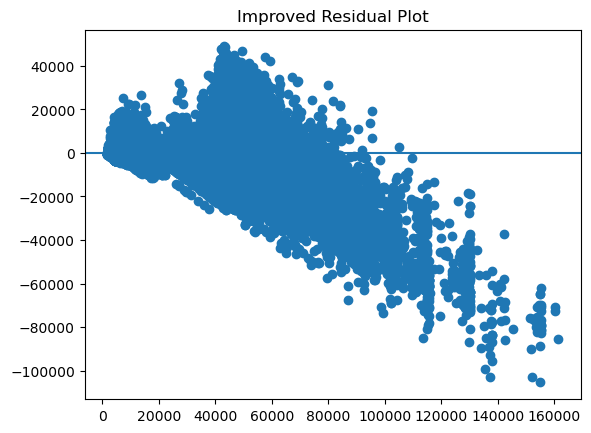

In [18]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.title("Improved Residual Plot")
plt.show()